# DataBases:

## 1. Relational Database:
Traditional (relational) databases store structured data in rows and columns to enable exact-match queries and transactional integrity

## 2. Vector Database:
Vector databases are built for AI applications; they store unstructured data (text, images, audio) as mathematical arrays called embeddings, allowing them to search by semantic meaning and similarity rather than exact keywords

A vector database is a specialized type of database designed to store, manage, and query "vector embeddings" (arrays of numbers that represent the meaning of unstructured data like text, images, or audio)

## Vector Databases:
a. FAISS  
b. Pinecone  
c. ChromaDB  
d. Weaviate  

## Example of Vector database

## Google image search

You upload a cat image.

System:

Image → Embedding

Search:

Find visually similar vectors

Results:

similar cats
same breed
related images

This is vector similarity search.

Suppose we have sentences:

"I love machine learning"
"AI is changing the world"
"The cat is sleeping"

Traditional databases search exact words.

Search:

"Artificial Intelligence"

Normal database may fail because:

"AI" ≠ "Artificial Intelligence"

But embeddings understand semantic meaning.

Embeddings convert text into vectors:

"I love machine learning"

↓

[0.21, -0.67, 0.90, ...]

Now similar meanings have nearby vectors.

Searching among millions of vectors requires a Vector Database.

In [2]:
!pip install pinecone sentence-transformers

In [3]:
from pinecone import Pinecone
from sentence_transformers import SentenceTransformer

In [4]:
from pinecone import ServerlessSpec

In [5]:
# this model converts sentence into embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
embedding_model

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

In [7]:
# Documents/sentences
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

In [8]:
# 2. Calculate embeddings by calling model.encode()
embeddings = embedding_model.encode(sentences)
print(embeddings.shape)

(3, 384)


In [9]:
embeddings

array([[ 0.01919577,  0.12008539,  0.15959834, ..., -0.00536285,
        -0.08109502,  0.05021336],
       [-0.01869039,  0.0415187 ,  0.07431544, ...,  0.00486599,
        -0.06190438,  0.03187511],
       [ 0.136502  ,  0.08227322, -0.02526163, ...,  0.08762044,
         0.03045843, -0.01075751]], dtype=float32)

In [10]:
# 3. Calculate the embedding similarities
similarities = embedding_model.similarity(embeddings, embeddings)
print(similarities)

tensor([[1.0000, 0.6660, 0.1046],
        [0.6660, 1.0000, 0.1411],
        [0.1046, 0.1411, 1.0000]])


In [11]:
# Initialize pinecone
pc = Pinecone(
    api_key="pcsk_2iAekd_PeuWzqKLWa1mYtNg4L54WDZnPSr8574JpFYy9qvWbWvwPB5rZqp3XFwxsWKE2rB"
)

### create Index
Index = table in vector database.


In [12]:
pc.create_index(
    name="semantic-search",
    dimension=384,
    metric="cosine",
        spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

ConflictError: [409 ALREADY_EXISTS] Resource  already exists

In [13]:
# connect to Index
index=pc.Index("semantic-search")

In [14]:
documents=[
"Machine learning is a subset of AI",
"Transformers process text",
"Deep learning uses neural networks",
"Cats are beautiful animals",
"Football is popular"
]

In [15]:
# convert documents to vectors
vectors=[]

for i,text in enumerate(documents):
    embedding=embedding_model.encode(text)

    vectors.append(
        (str(i),embedding.tolist(),{"text":text})
    )

In [16]:
# upload data to DB
index.upsert(vectors=vectors)

UpsertResponse(upserted_count=5)

## Semantic Search

In [17]:
query="Artificial Intelligence"

In [18]:
query_embedding = embedding_model.encode(query)

In [19]:
results=index.query(vector=query_embedding.tolist(), top_k=3, include_metadata=True)

In [20]:
results

QueryResponse(matches=[ScoredVector(id='0', score=0.57358557, values=[], metadata={'text': 'Machine learning is a subset of AI'}), ScoredVector(id='2', score=0.410479575, values=[], metadata={'text': 'Deep learning uses neural networks'}), ScoredVector(id='10', score=0.267992973, values=[], metadata={'text': 'Sentiment analysis predicts emotions from text'})], namespace='', usage=Usage(read_units=1, write_units=None), response_info=ResponseInfo(raw_headers={'date': 'Wed, 20 May 2026 11:50:35 GMT', 'content-type': 'application/json', 'content-length': '377', 'connection': 'keep-alive', 'x-pinecone-max-indexed-lsn': '3', 'x-pinecone-request-latency-ms': '44', 'x-envoy-upstream-service-time': '47', 'x-pinecone-response-duration-ms': '49', 'grpc-status': '0', 'server': 'envoy'}))

In [21]:
for match in results["matches"]:
    print(match["score"])

    print(match["metadata"]["text"])

0.57358557
Machine learning is a subset of AI
0.410479575
Deep learning uses neural networks
0.267992973
Sentiment analysis predicts emotions from text


# Semantic Search system

In [22]:
documents=[
"Tokenization splits text into smaller units called tokens",
"BPE is a subword tokenization algorithm",
"Transformers use self attention mechanisms",
"Attention helps models focus on relevant words",
"BERT is used for language understanding tasks",
"GPT is an autoregressive language model",
"Word embeddings convert words into vectors",
"LoRA reduces trainable parameters during fine tuning",
"Fine tuning adapts pretrained models to new tasks",
"Named Entity Recognition identifies names and locations",
"Sentiment analysis predicts emotions from text",
"Machine translation converts text between languages",
"Positional encoding gives sequence information",
"Multi head attention uses multiple attention mechanisms",
"Large language models learn from massive datasets",
"Decoder models generate text token by token",
"Encoder models create contextual representations",
"Hugging Face provides pretrained NLP models",
"RNN processes sequential information",
"LSTM solves long term dependency problems"
]

In [23]:
# convert documents to vectors
vectors=[]

for i,text in enumerate(documents):
    embedding=embedding_model.encode(text)

    vectors.append(
        (str(i),embedding.tolist(),{"text":text})
    )

In [24]:
# upload data to DB
index.upsert(vectors=vectors)

UpsertResponse(upserted_count=20)

In [25]:
query="How do transformers understand word positions?"

In [26]:
query_embedding = embedding_model.encode(query)

In [27]:
results=index.query(vector=query_embedding.tolist(), top_k=3, include_metadata=True)

In [28]:
for match in results["matches"]:
    print(match["score"])

    print(match["metadata"]["text"])

0.519497931
Transformers use self attention mechanisms
0.445316344
Positional encoding gives sequence information
0.443635
Machine translation converts text between languages


In [29]:
query="Method to reduce parameters during fine tuning"

In [30]:
query_embedding = embedding_model.encode(query)


In [31]:
results=index.query(vector=query_embedding.tolist(), top_k=3, include_metadata=True)

In [32]:
for match in results["matches"]:
    print(match["score"])

    print(match["metadata"]["text"])

0.563806057
LoRA reduces trainable parameters during fine tuning
0.497051746
Fine tuning adapts pretrained models to new tasks
0.178143516
Transformers use self attention mechanisms


# Mini Search Engine

In [34]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 7.4 MB/s eta 0:00:00


In [35]:
from pypdf import PdfReader

In [37]:
pc.create_index(name="mini-search-engine",dimension=384,metric="cosine",spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

IndexModel(name='mini-search-engine', metric='cosine', status=IndexStatus(ready=True, state='Ready'), spec=IndexSpec(serverless=ServerlessSpecInfo(cloud='aws', region='us-east-1', read_capacity={'mode': 'OnDemand', 'status': {'state': 'Ready', 'current_shards': None, 'current_replicas': None}}, source_collection=None, schema=None), pod=None, byoc=None), host='https://mini-search-engine-a8qr2h8.svc.aped-4627-b74a.pinecone.io', private_host=None, vector_type='dense', dimension=384, deletion_protection='disabled', tags=None, embed=None, created_at=None)

In [38]:
index = pc.Index("mini-search-engine")

In [39]:
# read pdf
reader = PdfReader("/content/37cc451f7925405c3cf9274863d488ba_Lecture1Final.pdf")

text = ""

for page in reader.pages:
    content = page.extract_text()
    if content:
        text += content

print("PDF Loaded")

PDF Loaded


In [40]:
chunk_size = 500

chunks = []

for i in range(0, len(text), chunk_size):
    chunks.append(text[i:i+chunk_size])

print("Chunks:",len(chunks))

Chunks: 114


In [41]:
import uuid

In [43]:
vectors=[]

for i,chunk in enumerate(chunks):

    emb=embedding_model.encode(chunk).tolist()

    vectors.append(
        {
            "id":str(uuid.uuid4()),
            "values":emb,
            "metadata":
            {
                "text":chunk,
                "chunk_id":i,
                "document":"/content/37cc451f7925405c3cf9274863d488ba_Lecture1Final.pdf"
            }
        }
    )

In [45]:
index.upsert(vectors=vectors)

print("Stored in Pinecone")

Stored in Pinecone


In [50]:
def search(query):

    query_emb=embedding_model.encode(query).tolist()

    result=index.query(
        vector=query_emb,
        top_k=3,
        include_metadata=True
    )

    output=""

    for match in result["matches"]:

        score=round(match["score"],3)

        text=match["metadata"]["text"]

        output+=f"""
Score: {score}

{text}
"""

    return output


In [51]:
r = search("What is Artificial Intelligence?")
print(r)


Score: 0.699

1
What is Artificial Intelligence (AI)? 
Lecture 1 • 1 
6.825 Techniques in Artificial Intelligence 
If you're going to teach or take an AI course, it's useful to ask: "What's AI?" 
It's a lot of different things to a lot of different people.  Let's go through a few 
things that AI is thought to be and situate them within the broader picture of 
AI. 2
What is Artificial Intelligence (AI)? 
• 
Lecture 1 • 2 
6.825 Techniques in Artificial Intelligence 
Computational models of human behavior? 
• P

Score: 0.67

ow they 
behave in certain situations and see if you could make computers behave in 
that same way.  Imagine that you wanted to make a program that played 
poker. Instead of making the best possible poker-playing program, you 
would make one that played poker like people do. 3
What is Artificial Intelligence (AI)? 
• 
• 
processes? 
Lecture 1 • 3 
6.825 Techniques in Artificial Intelligence 
Computational models of human behavior? 
• Programs that behave (externally

In [52]:
r = search("What are intelligent agents?")
print(r)


Score: 0.638

ns 
in the world and gathers information and takes action based on that 
information, to a factory, to all the airplanes belonging to United Airlines.  So, 
I will use that term very generically.  When I talk about computational agents 
that behave autonomously, I'll use agent as a shorthand for that. 8
The Agent and the Environment 
Lecture 1 • 8 
How do we begin to formalize the problem of building 
an agent? 
• Make a dichotomy between the agent and its environment 
• Not everyone believes th

Score: 0.634

e opposite extreme of putting all the intelligence in the brain, 
instead of in the hardware. 
We're going to try to be agnostic about the design of the hardware and work 
with people who do a good job of that, and take as given the computational 
problems it generates.  How can we formalize a computational problem of 
building an agent? 11
Lecture 1 • 11 
World Model 
What do we need to write down when we talk about the problem of making 
an agent? How can we spec

# Image Semantic Search

In [41]:
Image_embedding_model = SentenceTransformer("clip-ViT-B-32")

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [42]:
from PIL import Image

In [43]:
img = Image.open("/content/download2.png")

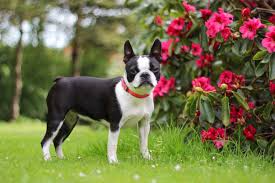

In [44]:
img

In [48]:
image_embedding=Image_embedding_model.encode(img, truncate_dim=512)

print(image_embedding.shape)

(512,)


In [49]:
# create_index
pc.create_index(name="image-search",dimension=512,metric="cosine",
                spec=ServerlessSpec(
                    cloud="aws",
                    region="us-east-1"
                    )
)

IndexModel(name='image-search', metric='cosine', host='https://image-search-a8qr2h8.svc.aped-4627-b74a.pinecone.io', status=IndexStatus(ready=True, state='Ready'), spec=IndexSpec(serverless=ServerlessSpecInfo(cloud='aws', region='us-east-1', read_capacity={'mode': 'OnDemand', 'status': {'state': 'Ready', 'current_shards': None, 'current_replicas': None}}, source_collection=None, schema=None), pod=None, byoc=None), vector_type='dense', dimension=512, deletion_protection='disabled', tags=None, embed=None, created_at=None)

In [50]:
index=pc.Index(
    "image-search"
)

In [51]:
files = [
    "/content/car.png",
    "/content/car1.png",
    "/content/dog running.png",
    "/content/dog running1.png",
    "/content/dog running2.png",
    "/content/dog sitting1.png",
    "/content/dog sitting2.png",
    "/content/download1.png",
    "/content/download2.png",
    "/content/person driving.png",
    "/content/person driving1.png",
    "/content/person eating.png",
    "/content/person eating1.png",
    "/content/person_hat.png",
    "/content/person_hat2.png",
    "/content/person_mask.png"
]

In [52]:
vectors=[]

for i,file in enumerate(files):
    img=Image.open(file)

    embedding=Image_embedding_model.encode(img)

    vectors.append(
        {
        "id":str(i),
        "values":embedding.tolist(),
        "metadata":{
            "filename":file
        }
        }
    )

In [53]:
index.upsert(
    vectors=vectors
)

UpsertResponse(upserted_count=16)

In [54]:
query=Image.open(
    "/content/car2.png"
)

In [56]:
query_embedding=Image_embedding_model.encode(
    query
)

In [57]:
results=index.query(
  vector=query_embedding.tolist(),
  top_k=3,
  include_metadata=True
)

In [58]:
import matplotlib.pyplot as plt

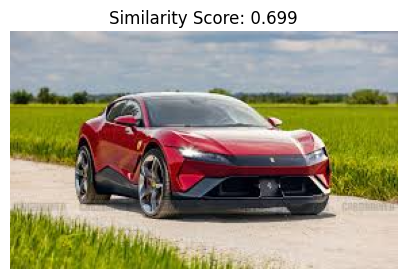

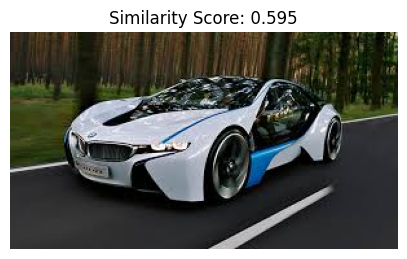

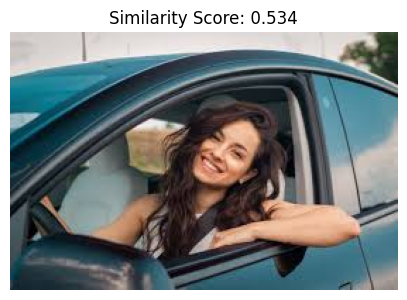

In [59]:
for match in results["matches"]:
    path = match["metadata"]["filename"]

    score = match["score"]

    img = Image.open(path)

    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.title(
        f"Similarity Score: {score:.3f}"
    )

    plt.axis("off")

    plt.show()

In [60]:
query=Image.open(
    "/content/person eating4.png"
)

In [61]:
query_embedding=Image_embedding_model.encode(
    query
)

In [62]:
results=index.query(
  vector=query_embedding.tolist(),
  top_k=3,
  include_metadata=True
)

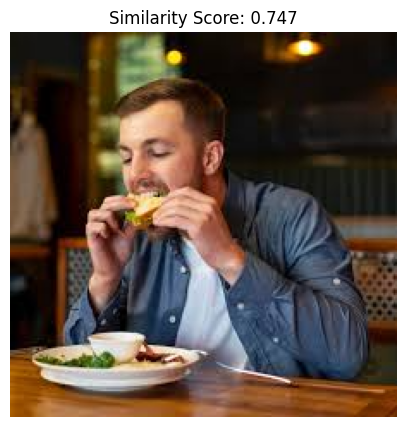

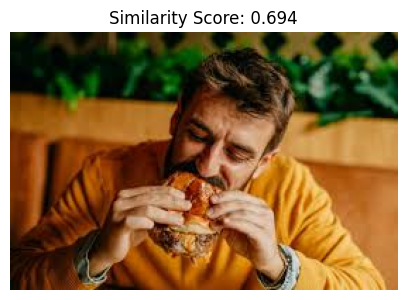

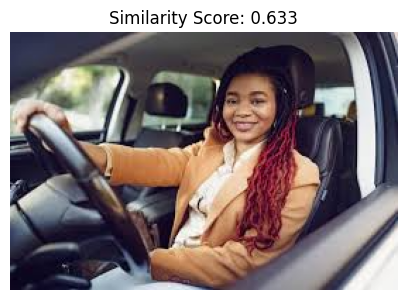

In [63]:
for match in results["matches"]:
    path = match["metadata"]["filename"]

    score = match["score"]

    img = Image.open(path)

    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.title(
        f"Similarity Score: {score:.3f}"
    )

    plt.axis("off")

    plt.show()